In [15]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, List

In [16]:
# =========================
# 1. 環境定義
# =========================

@dataclass
class EnvConfig:
    dt: float = 5.0                 # 每個 time-step 對應幾秒
    episode_duration: float = 3600  # 一個 episode = 幾秒 (預設 1 小時)
    lambda_ns: float = 0.25         # 南北方向到達率 (車/秒)
    lambda_ew: float = 0.25         # 東西方向到達率 (車/秒)
    discharge_rate: int = 1         # 綠燈方向每個 time-step 可通過幾輛車
    max_queue: int = 30             # queue 長度上限 (避免爆炸)
    switch_penalty: float = 2.0     # 每次切相位的額外懲罰


class SingleIntersectionEnv:
    """
    單一路口、兩個相位的簡化環境：
      - phase 0: NS 綠燈
      - phase 1: EW 綠燈
    state 用 (phase, NS queue bucket, EW queue bucket) 離散化成 50 個 state
    """

    def __init__(self, cfg: EnvConfig, seed: int = 0):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.steps_per_episode = int(cfg.episode_duration / cfg.dt)
        self._n_states = 2 * 5 * 5  # 2 phases * 5 NS buckets * 5 EW buckets
        self._n_actions = 2         # 0: keep, 1: switch
        self.reset()

    @property
    def n_states(self) -> int:
        return self._n_states

    @property
    def n_actions(self) -> int:
        return self._n_actions

    def _bucket(self, q: int) -> int:
        """把 queue 長度離散成 5 個 bucket。"""
        if q <= 0:
            return 0
        elif q <= 5:
            return 1
        elif q <= 10:
            return 2
        elif q <= 20:
            return 3
        else:
            return 4

    def _get_state_index(self) -> int:
        phase_idx = self.phase              # 0 or 1
        ns_b = self._bucket(self.queue_ns)  # 0~4
        ew_b = self._bucket(self.queue_ew)  # 0~4
        # 編碼方式：phase * 25 + ns_b * 5 + ew_b
        return phase_idx * 25 + ns_b * 5 + ew_b

    def reset(self) -> int:
        """重置環境，回傳離散 state index。"""
        self.queue_ns = 0
        self.queue_ew = 0
        self.phase = 0  # 初始給 NS 綠燈
        self.t = 0
        return self._get_state_index()

    def step(self, action: int) -> Tuple[int, float, bool, Dict]:
        """
        action: 0 = 保持目前相位, 1 = 切換相位
        回傳: (next_state_index, reward, done, info)
        """
        assert action in (0, 1)
        switched = (action == 1)
        if switched:
            self.phase = 1 - self.phase  # 切換 0<->1

        # 1) 車輛到達 (Poisson process)
        lam_ns = self.cfg.lambda_ns * self.cfg.dt
        lam_ew = self.cfg.lambda_ew * self.cfg.dt
        arrivals_ns = self.rng.poisson(lam_ns)
        arrivals_ew = self.rng.poisson(lam_ew)

        self.queue_ns = min(self.queue_ns + arrivals_ns, self.cfg.max_queue)
        self.queue_ew = min(self.queue_ew + arrivals_ew, self.cfg.max_queue)

        # 2) 綠燈方向排隊車輛通過
        if self.phase == 0:
            depart_ns = min(self.cfg.discharge_rate, self.queue_ns)
            self.queue_ns -= depart_ns
        else:
            depart_ew = min(self.cfg.discharge_rate, self.queue_ew)
            self.queue_ew -= depart_ew

        # 3) 計算 reward
        total_queue = self.queue_ns + self.queue_ew
        reward = -float(total_queue)
        if switched:
            reward -= self.cfg.switch_penalty

        # 4) 時間推進
        self.t += 1
        done = (self.t >= self.steps_per_episode)
        info = {
            "total_queue": total_queue,
            "queue_ns": self.queue_ns,
            "queue_ew": self.queue_ew,
            "phase": self.phase,
        }
        next_state = self._get_state_index()
        return next_state, reward, done, info

In [17]:
# =========================
# 2. Q-learning Agent
# =========================

@dataclass
class QLearningConfig:
    gamma: float = 0.99
    alpha: float = 0.1      # 學習率
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_episodes: int = 400  # 在前多少 episode 線性衰減 epsilon
    n_episodes: int = 800


class QLearningAgent:
    def __init__(self, n_states: int, n_actions: int, cfg: QLearningConfig, seed: int = 0):
        self.n_states = n_states
        self.n_actions = n_actions
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.Q = np.zeros((n_states, n_actions), dtype=np.float64)

    def _epsilon_for_episode(self, episode: int) -> float:
        """線性衰減 epsilon。"""
        frac = min(episode / self.cfg.epsilon_decay_episodes, 1.0)
        return self.cfg.epsilon_start + frac * (self.cfg.epsilon_end - self.cfg.epsilon_start)

    def select_action(self, state: int, episode: int) -> int:
        epsilon = self._epsilon_for_episode(episode)
        if self.rng.random() < epsilon:
            return self.rng.integers(self.n_actions)  # 探索
        else:
            # 利用：選 Q 值最大的 action
            return int(np.argmax(self.Q[state]))

    def update(self, s: int, a: int, r: float, s_next: int):
        """Tabular Q-learning 更新。"""
        best_next = np.max(self.Q[s_next])
        td_target = r + self.cfg.gamma * best_next
        td_error = td_target - self.Q[s, a]
        self.Q[s, a] += self.cfg.alpha * td_error

In [18]:
# =========================
# 3. 訓練與評估流程
# =========================

def train_q_learning(env_cfg: EnvConfig,
                     q_cfg: QLearningConfig,
                     seed: int = 0):
    env = SingleIntersectionEnv(env_cfg, seed=seed)
    agent = QLearningAgent(env.n_states, env.n_actions, q_cfg, seed=seed)

    episode_rewards: List[float] = []
    episode_mean_queues: List[float] = []

    for ep in range(q_cfg.n_episodes):
        s = env.reset()
        total_reward = 0.0
        total_queue = 0.0
        steps = 0

        while True:
            a = agent.select_action(s, ep)
            s_next, r, done, info = env.step(a)
            agent.update(s, a, r, s_next)

            total_reward += r
            total_queue += info["total_queue"]
            steps += 1

            s = s_next
            if done:
                break

        mean_queue = total_queue / steps
        episode_rewards.append(total_reward)
        episode_mean_queues.append(mean_queue)

        if (ep + 1) % 50 == 0:
            print(f"[Train] Episode {ep+1}/{q_cfg.n_episodes}, "
                  f"total_reward={total_reward:.1f}, mean_queue={mean_queue:.2f}")

    return env_cfg, agent, episode_rewards, episode_mean_queues


def evaluate_policy(env_cfg: EnvConfig,
                    Q: np.ndarray,
                    n_episodes: int = 50,
                    seed: int = 1234):
    """
    用學到的 Q 表評估表現，只做 greedy policy。
    回傳：平均 total_queue、平均 reward。
    """
    env = SingleIntersectionEnv(env_cfg, seed=seed)
    n_states, n_actions = Q.shape

    total_rewards = []
    mean_queues = []

    for ep in range(n_episodes):
        s = env.reset()
        total_reward = 0.0
        total_queue = 0.0
        steps = 0

        while True:
            a = int(np.argmax(Q[s]))  # greedy
            s_next, r, done, info = env.step(a)
            total_reward += r
            total_queue += info["total_queue"]
            steps += 1
            s = s_next
            if done:
                break

        total_rewards.append(total_reward)
        mean_queues.append(total_queue / steps)

    return {
        "avg_total_reward": float(np.mean(total_rewards)),
        "std_total_reward": float(np.std(total_rewards)),
        "avg_mean_queue": float(np.mean(mean_queues)),
        "std_mean_queue": float(np.std(mean_queues)),
    }


def simulate_fixed_time_policy(env_cfg: EnvConfig,
                               phase_duration_steps: int = 12,
                               n_episodes: int = 50,
                               seed: int = 5678):
    """
    Baseline：固定時間交替相位
      - 每 phase_duration_steps 個 time-step 切相位一次。
    """
    env = SingleIntersectionEnv(env_cfg, seed=seed)

    total_rewards = []
    mean_queues = []

    for ep in range(n_episodes):
        s = env.reset()
        total_reward = 0.0
        total_queue = 0.0
        steps = 0
        steps_in_phase = 0

        while True:
            # 是否要切相位？
            if steps_in_phase >= phase_duration_steps:
                action = 1  # 切換
                steps_in_phase = 0
            else:
                action = 0  # 保持
                steps_in_phase += 1

            s_next, r, done, info = env.step(action)
            total_reward += r
            total_queue += info["total_queue"]
            steps += 1
            s = s_next

            if done:
                break

        total_rewards.append(total_reward)
        mean_queues.append(total_queue / steps)

    return {
        "avg_total_reward": float(np.mean(total_rewards)),
        "std_total_reward": float(np.std(total_rewards)),
        "avg_mean_queue": float(np.mean(mean_queues)),
        "std_mean_queue": float(np.std(mean_queues)),
    }


In [19]:
def run_episode_with_logging(env_cfg: EnvConfig,
                             policy: str = "rl",
                             agent: QLearningAgent | None = None,
                             phase_duration_steps: int = 12,
                             seed: int = 0):
    """
    跑一個 episode，完整紀錄時間序列。
    policy:
      - "rl": 使用 agent 的 greedy policy (argmax Q)
      - "fixed": 固定時制，每 phase_duration_steps step 切一次相位
    回傳 dict，包括：
      "queue_ns", "queue_ew", "phase", "action", "total_queue"
    """
    env = SingleIntersectionEnv(env_cfg, seed=seed)

    if policy == "rl":
        assert agent is not None, "policy='rl' 需要傳入訓練好的 agent"

    s = env.reset()
    T = env.steps_per_episode

    queue_ns = []
    queue_ew = []
    phase_hist = []
    action_hist = []
    total_queue_hist = []

    steps_in_phase = 0

    for t in range(T):
        if policy == "rl":
            # greedy policy
            a = int(np.argmax(agent.Q[s]))
        elif policy == "fixed":
            # 固定時制：每 phase_duration_steps 個 step 切一次
            if steps_in_phase >= phase_duration_steps:
                a = 1   # 切換
                steps_in_phase = 0
            else:
                a = 0   # 保持
                steps_in_phase += 1
        else:
            raise ValueError(f"Unknown policy: {policy}")

        s_next, r, done, info = env.step(a)

        queue_ns.append(info["queue_ns"])
        queue_ew.append(info["queue_ew"])
        phase_hist.append(info["phase"])
        action_hist.append(a)
        total_queue_hist.append(info["total_queue"])

        s = s_next
        if done:
            break

    return {
        "queue_ns": np.array(queue_ns),
        "queue_ew": np.array(queue_ew),
        "phase": np.array(phase_hist),
        "action": np.array(action_hist),
        "total_queue": np.array(total_queue_hist),
    }


[Train] Episode 50/10000, total_reward=-1821.0, mean_queue=1.53
[Train] Episode 100/10000, total_reward=-1400.0, mean_queue=1.03
[Train] Episode 150/10000, total_reward=-1155.0, mean_queue=0.72
[Train] Episode 200/10000, total_reward=-1306.0, mean_queue=1.04
[Train] Episode 250/10000, total_reward=-1482.0, mean_queue=1.30
[Train] Episode 300/10000, total_reward=-848.0, mean_queue=0.53
[Train] Episode 350/10000, total_reward=-942.0, mean_queue=0.71
[Train] Episode 400/10000, total_reward=-902.0, mean_queue=0.68
[Train] Episode 450/10000, total_reward=-658.0, mean_queue=0.45
[Train] Episode 500/10000, total_reward=-974.0, mean_queue=0.80
[Train] Episode 550/10000, total_reward=-767.0, mean_queue=0.61
[Train] Episode 600/10000, total_reward=-772.0, mean_queue=0.56
[Train] Episode 650/10000, total_reward=-566.0, mean_queue=0.37
[Train] Episode 700/10000, total_reward=-682.0, mean_queue=0.51
[Train] Episode 750/10000, total_reward=-939.0, mean_queue=0.77
[Train] Episode 800/10000, total_rew

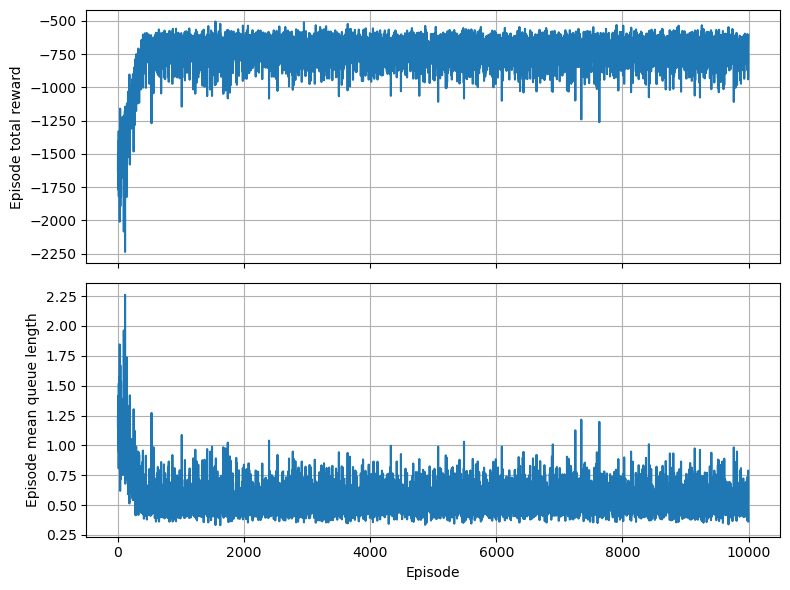


[RL policy evaluation]
{'avg_total_reward': -669.75, 'std_total_reward': 67.8327907431207, 'avg_mean_queue': 0.5083472222222222, 'std_mean_queue': 0.07919382940444754}

[Fixed-time baseline evaluation]
{'avg_total_reward': -1886.89, 'std_total_reward': 178.91897020718625, 'avg_mean_queue': 2.467902777777778, 'std_mean_queue': 0.2484985697322031}


In [20]:
# =========================
# 4. 主程式執行 & 繪圖
# =========================


# ---- 參數設定 ----
env_cfg = EnvConfig(
    dt=5.0,
    episode_duration=3600.0,
    lambda_ns=0.05,   # ↓ 原本 0.25
    lambda_ew=0.05,   # ↓ 原本 0.25
    discharge_rate=1,
    max_queue=30,
    switch_penalty=2.0,
)
q_cfg = QLearningConfig(
    gamma=0.99,
    alpha=0.1,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_episodes=400,
    n_episodes=10000,
)

# ---- 訓練 Q-learning ----
env_cfg, agent, ep_rewards, ep_mean_queues = train_q_learning(env_cfg, q_cfg, seed=0)

# ---- 繪製訓練曲線 ----
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(ep_rewards)
axes[0].set_ylabel("Episode total reward")
axes[0].grid(True)

axes[1].plot(ep_mean_queues)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Episode mean queue length")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ---- 評估學到的策略 ----
rl_stats = evaluate_policy(env_cfg, agent.Q, n_episodes=100, seed=1)
print("\n[RL policy evaluation]")
print(rl_stats)

# ---- Baseline: 固定時制策略 ----
baseline_stats = simulate_fixed_time_policy(env_cfg,
                                            phase_duration_steps=12,
                                            n_episodes=100,
                                            seed=2)
print("\n[Fixed-time baseline evaluation]")
print(baseline_stats)


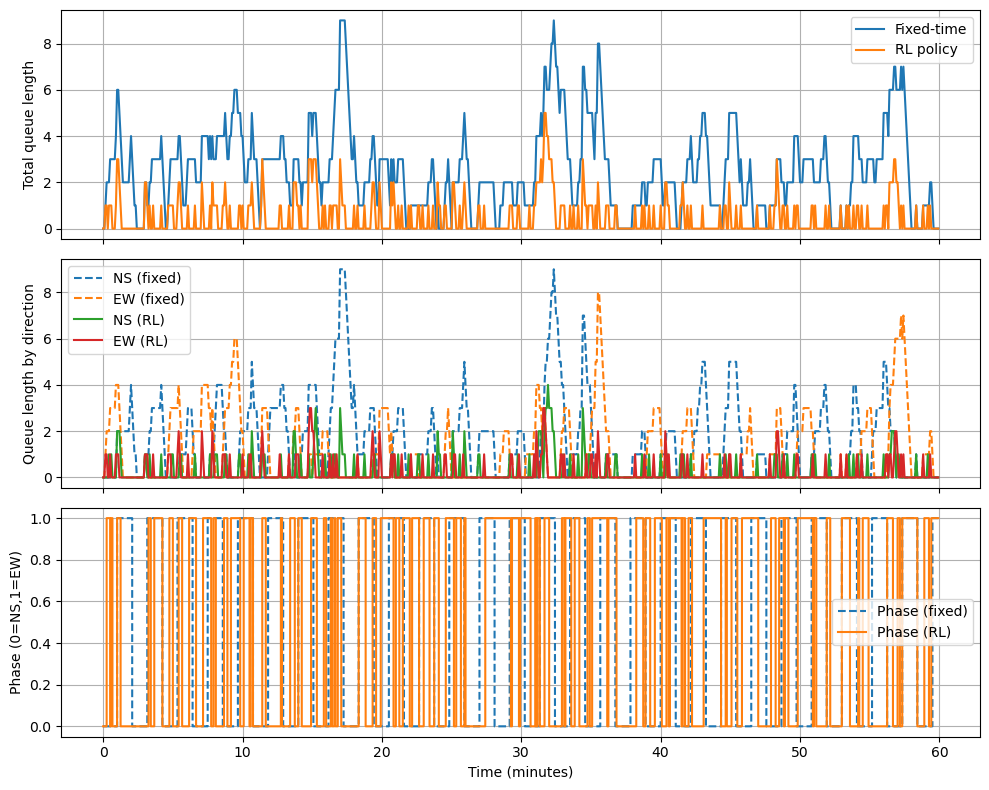

In [21]:
# ---- 取一個代表性的 episode，畫出 RL vs fixed-time ----
log_rl = run_episode_with_logging(env_cfg, policy="rl", agent=agent, seed=123)
log_fix = run_episode_with_logging(env_cfg, policy="fixed", phase_duration_steps=12, seed=123)

t = np.arange(len(log_rl["queue_ns"])) * env_cfg.dt / 60.0  # 轉成分鐘

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# (a) 總 queue 比較
axes[0].plot(t, log_fix["total_queue"], label="Fixed-time")
axes[0].plot(t, log_rl["total_queue"], label="RL policy")
axes[0].set_ylabel("Total queue length")
axes[0].legend()
axes[0].grid(True)

# (b) 南北 / 東西 queue 比較
axes[1].plot(t, log_fix["queue_ns"], linestyle="--", label="NS (fixed)")
axes[1].plot(t, log_fix["queue_ew"], linestyle="--", label="EW (fixed)")
axes[1].plot(t, log_rl["queue_ns"], label="NS (RL)")
axes[1].plot(t, log_rl["queue_ew"], label="EW (RL)")
axes[1].set_ylabel("Queue length by direction")
axes[1].legend()
axes[1].grid(True)

# (c) 號誌相位隨時間
# phase: 0 = NS 綠燈, 1 = EW 綠燈
axes[2].step(t, log_fix["phase"], where="post", linestyle="--", label="Phase (fixed)")
axes[2].step(t, log_rl["phase"], where="post", label="Phase (RL)")
axes[2].set_ylabel("Phase (0=NS,1=EW)")
axes[2].set_xlabel("Time (minutes)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


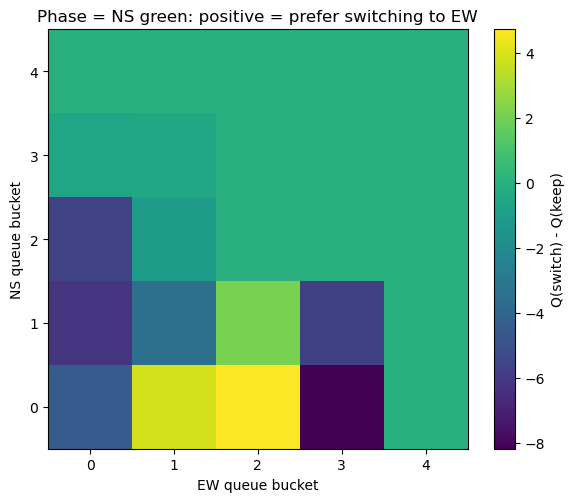

In [22]:
# ---- Policy heatmap：phase=0 (NS 綠燈) 時，什麼情況會切換？ ----
Q = agent.Q  # 形狀 (n_states, 2)
n_buckets = 5

# 我們看 phase = 0 的情況
switch_advantage = np.zeros((n_buckets, n_buckets))  # [ns_b, ew_b] -> Q_switch - Q_keep

for ns_b in range(n_buckets):
    for ew_b in range(n_buckets):
        state_idx = 0 * 25 + ns_b * 5 + ew_b  # phase=0
        q_keep = Q[state_idx, 0]   # action=0: keep phase
        q_switch = Q[state_idx, 1] # action=1: switch phase
        switch_advantage[ns_b, ew_b] = q_switch - q_keep

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(switch_advantage, origin="lower", aspect="equal")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Q(switch) - Q(keep)")

ax.set_xlabel("EW queue bucket")
ax.set_ylabel("NS queue bucket")
ax.set_title("Phase = NS green: positive = prefer switching to EW")

ax.set_xticks(range(n_buckets))
ax.set_yticks(range(n_buckets))
plt.tight_layout()
plt.show()
